In [ ]:
# Clone the repository containing the entire dataset directly from GitHub
!git clone https://github.com/RohitVenkatMutyala/face-classification-dataset.git


Saving dataset_80_10_10.zip to dataset_80_10_10.zip


In [ ]:
import os

# Verify the repository and dataset directories exist
print("Files in /content:", os.listdir("/content"))
print("Dataset folders:", os.listdir("/content/face-classification-dataset/dataset"))


['.config', 'dataset_80_10_10.zip', 'drive', 'content', 'sample_data']


In [ ]:
import os
import glob

DATASET_DIR = "/content/face-classification-dataset/dataset"

for cls in ["class_A", "class_B", "class_A2"]:
    print("\n" + cls)
    for split in ["train", "val", "test"]:
        path = os.path.join(DATASET_DIR, cls, split)
        if os.path.exists(path):
            all_files = os.listdir(path)
            print(f"\n{split}")
            print("Path:", path)
            print("Total files:", len(all_files))
            print("First 5 files:", all_files[:5])



class_A


FileNotFoundError: [Errno 2] No such file or directory: '/content/dataset_80_10_10/class_A/train'

In [ ]:
import os

print("Folders/files directly inside /content:")
print(os.listdir("/content"))

Folders/files directly inside /content:
['.config', 'dataset_80_10_10.zip', 'drive', 'content', 'sample_data']


In [ ]:
import os

for root, dirs, files in os.walk("/content"):
    if "class_A" in dirs or "class_B" in dirs:
        print("FOUND:", root)
        print("Directories:", dirs)
        print()

FOUND: /content/content/dataset_80_10_10
Directories: ['class_A', 'class_B']



In [ ]:
import os

for root, dirs, files in os.walk("/content/content"):
    if "class_A" in dirs:
        print("class_A found at:")
        print(os.path.join(root, "class_A"))

class_A found at:
/content/content/dataset_80_10_10/class_A


In [ ]:
DATASET_DIR = "/content/face-classification-dataset/dataset"


In [ ]:
for cls in ["class_A", "class_B", "class_A2"]:
    print("\n" + cls)
    for split in ["train", "val", "test"]:
        path = os.path.join(
            DATASET_DIR,
            cls,
            split
        )
        if os.path.exists(path):
            images = [
                f for f in os.listdir(path)
                if f.lower().endswith(
                    (".jpg", ".jpeg", ".png")
                )
            ]
            print(f"{split}: {len(images)}")



class_A
train: 800
val: 100
test: 100

class_B
train: 800
val: 100
test: 100


In [ ]:
import os
import tensorflow as tf

DATASET_DIR = "/content/face-classification-dataset/dataset"

print("Dataset exists:", os.path.exists(DATASET_DIR))


Dataset exists: True


In [ ]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

In [ ]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATASET_DIR, "class_A"),
    labels="inferred",
    label_mode="binary",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

Found 1000 files belonging to 3 classes.


ValueError: When passing `label_mode="binary"`, there must be exactly 2 class_names. Received: class_names=['test', 'train', 'val']

In [ ]:
import os
import shutil

DATASET_DIR = "/content/face-classification-dataset/dataset"
ML_DATASET = "/content/ml_dataset"

for split in ["train", "val", "test"]:
    for cls in ["class_A", "class_B"]:
        os.makedirs(
            os.path.join(ML_DATASET, split, cls),
            exist_ok=True
        )

print("Directories created.")


Directories created.


In [ ]:
import os
import shutil

DATASET_DIR = "/content/face-classification-dataset/dataset"
ML_DATASET = "/content/ml_dataset"

for split in ["train", "val", "test"]:
    # 1. Copy Class A (Teammate) images to class_A
    src_a = os.path.join(DATASET_DIR, "class_A", split)
    dst_a = os.path.join(ML_DATASET, split, "class_A")
    if os.path.exists(src_a):
        for filename in os.listdir(src_a):
            shutil.copy2(os.path.join(src_a, filename), os.path.join(dst_a, filename))

    # 2. Copy Class A2 (User) images also to class_A
    src_a2 = os.path.join(DATASET_DIR, "class_A2", split)
    if os.path.exists(src_a2):
        for filename in os.listdir(src_a2):
            shutil.copy2(os.path.join(src_a2, filename), os.path.join(dst_a, filename))

    # 3. Copy Class B (Professor) images to class_B
    src_b = os.path.join(DATASET_DIR, "class_B", split)
    dst_b = os.path.join(ML_DATASET, split, "class_B")
    if os.path.exists(src_b):
        for filename in os.listdir(src_b):
            shutil.copy2(os.path.join(src_b, filename), os.path.join(dst_b, filename))

print("All images copied and merged (class_A and class_A2 under class_A).")


All images copied.


In [ ]:
import glob
import os

for split in ["train", "val", "test"]:

    print("\n" + split)

    for cls in ["class_A", "class_B"]:

        path = os.path.join(
            ML_DATASET,
            split,
            cls
        )

        images = [
            f for f in os.listdir(path)
            if f.lower().endswith(
                (".jpg", ".jpeg", ".png")
            )
        ]

        print(
            f"{cls}: {len(images)}"
        )


train
class_A: 800
class_B: 800

val
class_A: 100
class_B: 100

test
class_A: 100
class_B: 100


In [ ]:
import tensorflow as tf

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/ml_dataset/train",
    labels="inferred",
    label_mode="binary",
    class_names=["class_A", "class_B"],
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

Found 1600 files belonging to 2 classes.


In [ ]:
val_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/ml_dataset/val",
    labels="inferred",
    label_mode="binary",
    class_names=["class_A", "class_B"],
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 200 files belonging to 2 classes.


In [ ]:
test_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/ml_dataset/test",
    labels="inferred",
    label_mode="binary",
    class_names=["class_A", "class_B"],
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 200 files belonging to 2 classes.


In [ ]:
print(train_ds.class_names)

['class_A', 'class_B']


In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

/tmp/ipykernel_1160/1840973936.py:15: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  label = int(labels[i].numpy())


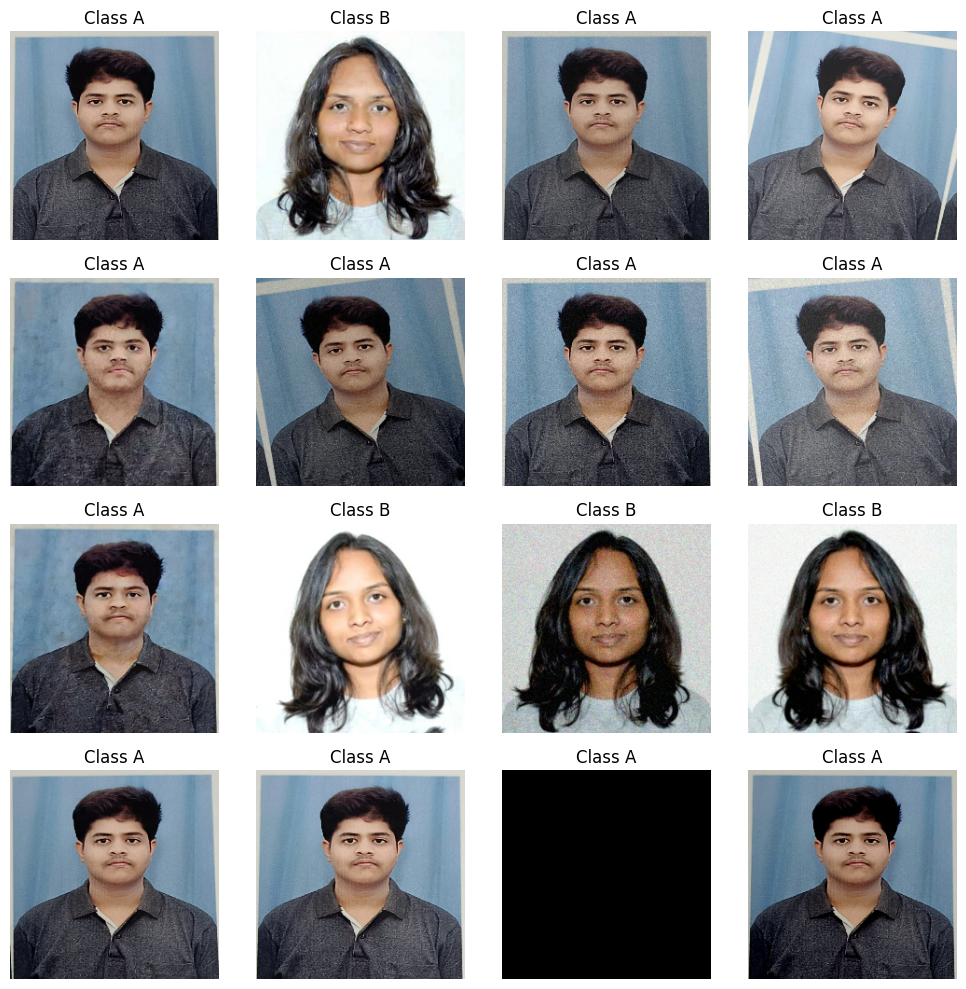

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))

for images, labels in train_ds.take(1):

    for i in range(min(16, len(images))):

        plt.subplot(4, 4, i + 1)

        plt.imshow(
            images[i].numpy().astype("uint8")
        )

        label = int(labels[i].numpy())

        plt.title(
            "Class A" if label == 0 else "Class B"
        )

        plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2

base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

print("MobileNetV2 loaded")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
MobileNetV2 loaded


In [ ]:
base_model.trainable = False

In [ ]:
inputs = layers.Input(
    shape=(224, 224, 3)
)

# MobileNetV2 preprocessing
x = tf.keras.applications.mobilenet_v2.preprocess_input(
    inputs
)

# Pretrained feature extractor
x = base_model(
    x,
    training=False
)

# Convert feature maps into a vector
x = layers.GlobalAveragePooling2D()(x)

# Reduce overfitting
x = layers.Dropout(0.3)(x)

# Two-class output
outputs = layers.Dense(
    1,
    activation="sigmoid"
)(x)

model = tf.keras.Model(
    inputs=inputs,
    outputs=outputs
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-4
    ),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(
            name="precision"
        ),
        tf.keras.metrics.Recall(
            name="recall"
        )
    ]
)

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 40s 449ms/step - accuracy: 0.5225 - loss: 0.7835 - precision: 0.5148 - recall: 0.7837 - val_accuracy: 0.8600 - val_loss: 0.4952 - val_precision: 0.7812 - val_recall: 1.0000
Epoch 2/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 102ms/step - accuracy: 0.8875 - loss: 0.3896 - precision: 0.8392 - recall: 0.9588 - val_accuracy: 1.0000 - val_loss: 0.2580 - val_precision: 1.0000 - val_recall: 1.0000
Epoch 3/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 144ms/step - accuracy: 0.9869 - loss: 0.2302 - precision: 0.9803 - recall: 0.9937 - val_accuracy: 1.0000 - val_loss: 0.1545 - val_precision: 1.0000 - val_recall: 1.0000
Epoch 4/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 101ms/step - accuracy: 0.9981 - loss: 0.1468 - precision: 0.9963 - recall: 1.0000 - val_accuracy: 1.0000 - val_loss: 0.1029 - val_precision: 1.0000 - val_recall: 1.0000
Epoch 5/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 107ms/step - accuracy: 0.9987 - loss: 0.1027 - precision: 0.9975 - recall: 1.0000 - val_accuracy: 1.0000 - val_loss: 0

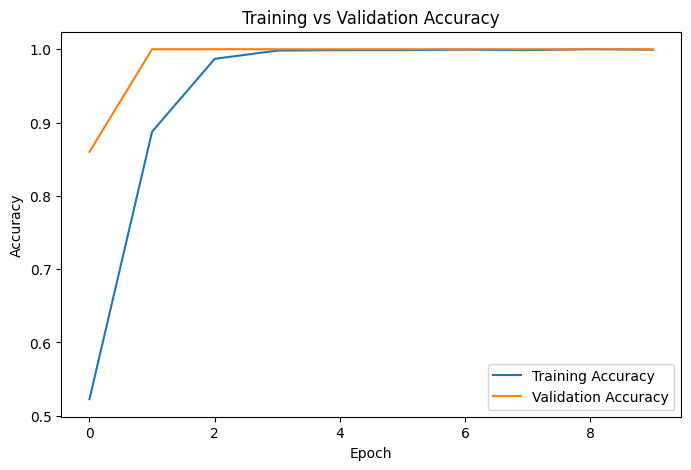

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

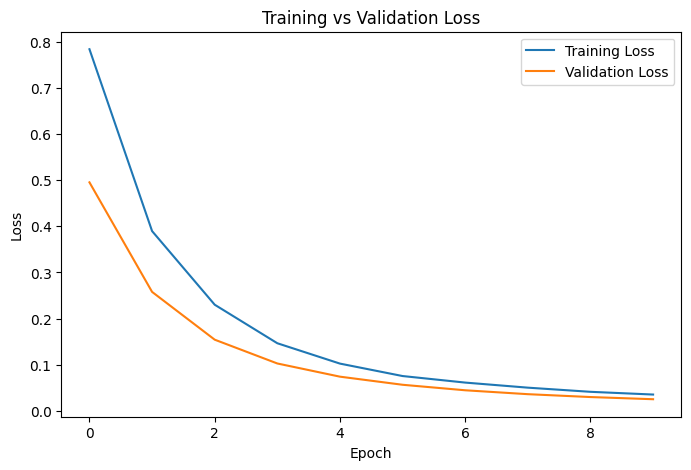

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

In [ ]:
test_results = model.evaluate(
    test_ds,
    return_dict=True
)

print("\nTest Results")

for name, value in test_results.items():
    print(
        f"{name}: {value:.4f}"
    )

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 120ms/step - accuracy: 1.0000 - loss: 0.0270 - precision: 1.0000 - recall: 1.0000

Test Results
accuracy: 1.0000
loss: 0.0270
precision: 1.0000
recall: 1.0000


In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

y_true = []
y_pred = []
y_prob = []

for images, labels in test_ds:

    probabilities = model.predict(
        images,
        verbose=0
    ).flatten()

    predictions = (
        probabilities >= 0.5
    ).astype(int)

    y_true.extend(
        labels.numpy().astype(int)
    )

    y_pred.extend(predictions)

    y_prob.extend(probabilities)

In [ ]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=[
            "Class A",
            "Class B"
        ]
    )
)

              precision    recall  f1-score   support

     Class A       1.00      1.00      1.00       100
     Class B       1.00      1.00      1.00       100

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



In [ ]:
cm = confusion_matrix(
    y_true,
    y_pred
)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[100   0]
 [  0 100]]


In [ ]:
model.save(
    "/content/face_classifier.keras"
)

print("Model saved.")

Model saved.


In [ ]:
import os

print(
    os.path.exists(
        "/content/face_classifier.keras"
    )
)

True


In [ ]:
from google.colab import files

files.download(
    "/content/face_classifier.keras"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import tensorflow as tf

model = tf.keras.models.load_model(
    "/content/face_classifier.keras"
)

print("Model loaded successfully")

Model loaded successfully
